In [2]:
import pandas as pd
import numpy as np
from lxml import etree
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
n_chunks = 50
# src_file = "ajtzibab.txt"

# Read XML

In [4]:
src_file = 'source.v1.tei.xml'
ns = {"tei": "http://www.tei-c.org/ns/1.0", 
      "xml": "http://www.w3.org/TR/html4"}
p_xpath = "//tei:body//tei:p"

In [5]:
tree = etree.parse(src_file)  # Replace with your actual file path
root = tree.getroot()
p_elements = root.xpath(p_xpath, namespaces=ns)

In [6]:
def extract_text_excluding_notes(elem):
    
    # Grab paragraph ID
    p_id_list = elem.xpath('./@xml:id', namespaces=ns)
    if len(p_id_list) == 0:
        p_id = None
    else:
        p_id = float(p_id_list[0].replace('p', ''))
    
    # Serialize the <p> element to string    
    p_str = etree.tostring(elem, encoding="unicode")
    
    # Wrap it in a dummy root element
    wrapped = f"<wrapper xmlns='http://www.tei-c.org/ns/1.0'>{p_str}</wrapper>"
    wrapper_elem = etree.fromstring(wrapped)

    # Remove all <note> elements
    for note in wrapper_elem.xpath(".//tei:note", namespaces=ns):
        note.getparent().remove(note)

    # Get all remaining <p> elements and concatenate their text
    text_parts = []
    for p in wrapper_elem.xpath(".//tei:p", namespaces=ns):
        text_parts.append(''.join(p.itertext()))
    p_text = ' '.join(text_parts)

    # Return id and text
    return (p_id, p_text)

paragraphs = [extract_text_excluding_notes(p) for p in p_elements]

In [7]:
# Convert to dataframe
PARA = pd.DataFrame(paragraphs, columns=['para_id', 'para_str'])
PARA.para_id = PARA.para_id.ffill()
PARA.loc[PARA.para_id.isna(), 'para_id'] = 0
PARA.para_id = PARA.para_id.astype(int)
PARA['line_id'] = PARA.groupby('para_id').cumcount() + 1
PARA = PARA.set_index(['para_id','line_id'])

In [8]:
PARA

para_str
para_id line_id                                    
0       1                                 POPOL WUJ
        2                             OJER TAQ TZIJ
        3                 XB'AN PA TINAMIT K'ICHE',
        4                      RAMAQ' K'ICHE' WINAQ
        5                        \n        \n      
...                                             ...
152     8              rumal maja b'i chi ilb'al re
        9              k'o nab'e ojer kumal ajawab'
        10                           sachinaq chik.
        11       Xere k'u ri mixutzinik chi konojel
        12                 K'iche' Sta. Cruz ub'i'.

[6278 rows x 1 columns]

In [9]:
# Convert paragraphs to tokens
TOKEN = PARA.para_str.str.split(expand=True).stack().to_frame('token_str')
TOKEN.index.names = PARA.index.names + ['token_num']

In [10]:
# Create normalized terms from tokens
TOKEN['term_str'] = (
    TOKEN
        .token_str.str.replace(r"\d+", "", regex=True)
        .str.replace('.', '')
        .str.replace(',', '')
        .str.lower()
        .str.strip()
)

# Remove blanks
TOKEN = TOKEN[~TOKEN.term_str.str.match(r'^\s*$')]

In [11]:
# Create a document-term matrix to extract statistics
DTM = TOKEN.groupby(['para_id', 'term_str']).term_str.count().unstack(fill_value=0)

In [12]:
DTM

term_str,a,a',a'on,ab'aj,ab'ajil,ab'anel,ab'anoj,ab'i',ab'ix,ab'ixik,...,yan,ye'oltux,yitz',yitz'il,yojol,yolkwat,yoq'b'al,yoq'otajinaq,yub'jan,yujuj
para_id,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
149,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
150,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
VOCAB = DTM.sum().to_frame('n')
VOCAB['p'] = VOCAB.n / VOCAB.n.sum()

In [14]:
VOCAB

,n,p
term_str,,
a,38,0.001447
a',6,0.000228
a'on,1,0.000038
ab'aj,26,0.000990
ab'ajil,1,0.000038
...,...,...
yolkwat,1,0.000038
yoq'b'al,1,0.000038
yoq'otajinaq,1,0.000038


In [15]:
VOCAB['i'] = np.log2(1/VOCAB.p)

In [16]:
# Compute DFIDF to select significant terms
VOCAB['df'] = DTM.astype(bool).sum()
VOCAB['dp'] = VOCAB.df / len(DTM)
VOCAB['di'] = np.log2(1/VOCAB.dp)
VOCAB['dh'] = VOCAB.dp * VOCAB.di
# VOCAB['dfidf'] = VOCAB.df * np.log2(len(DTM)/VOCAB.df)

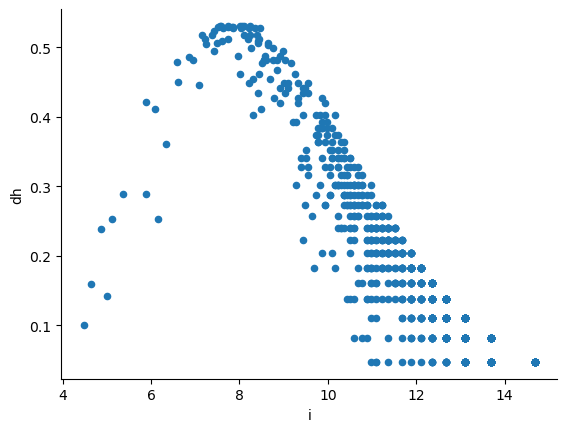

In [17]:
VOCAB.plot.scatter('i', 'dh')
sns.despine()
plt.show()

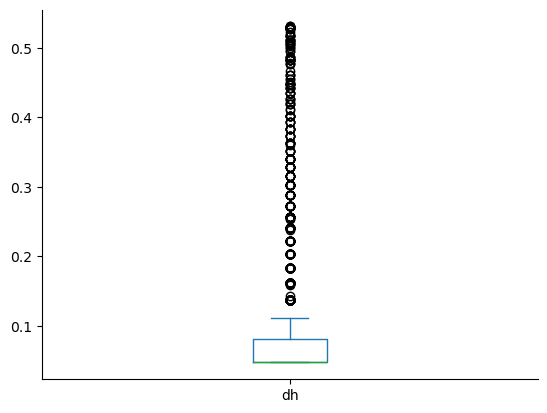

In [18]:
VOCAB.dh.plot.box()
sns.despine()
plt.show()

In [19]:
# VOCAB['dh_group'] = VOCAB.dh.round(4).astype(int)

In [20]:
# VOCAB.groupby('dh_group').count().n.sort_index().plot.bar();

In [21]:
# VOCAB[VOCAB.dfidf_group >= 8]

In [22]:
# VOCAB[VOCAB.dfidf_group < 8]

In [23]:
# Chunk
# n_chunks = 25

In [24]:
OHCO = TOKEN.index.names
try:
    TOKEN = TOKEN.reset_index().reset_index().set_index(OHCO)
except ValueError as e:
    pass
TOKEN

index token_str term_str
para_id line_id token_num                          
0       1       0              0     POPOL    popol
                1              1       WUJ      wuj
        2       0              2      OJER     ojer
                1              3       TAQ      taq
                2              4      TZIJ     tzij
...                          ...       ...      ...
152     11      5          26259   konojel  konojel
        12      0          26260   K'iche'  k'iche'
                1          26261      Sta.      sta
                2          26262      Cruz     cruz
                3          26263    ub'i'.    ub'i'

[26264 rows x 3 columns]

In [25]:
n_chunks = 60
CHUNK = TOKEN.groupby(pd.cut(TOKEN['index'], n_chunks), observed=True)\
    .term_str.apply(lambda x: ' '.join(x))\
    .reset_index(drop=True)\
    .to_frame('chunk_str')
CHUNK.index.name = 'chunk_id'
CHUNK['n_tokens'] = CHUNK.chunk_str.str.split().str.len()
CHUNK

,chunk_str,n_tokens
chunk_id,,
0,popol wuj ojer taq tzij xb'an pa tinamit k'ich...,438
1,taj chijamataj chiwinaqir wa ulew ulaq'el ch'a...,438
2,nimachikop k'o chuwach ulew ta xraj k'u kitij ...,438
3,b'it katk'ix la uloq at uk'u'x kaj maqajisaj u...,437
4,ri kixk'ub' chitaninik chipe pa q'aq' tak'al c...,438
5,ri chi k'u ri kab'raqan chisilab' juyub' rumal...,438
6,kaqix ri mama' ati't kachb'ilan kib' a pa kixp...,438
7,at k'ajol k'o pa' achuch aqajaw maja b'i xcha'...,437
8,richilana mixqab'ano k'a xecha' chi kib'il kib...,438


In [26]:
# import warnings
# warnings.filterwarnings("ignore", category=FutureWarning, message=".*swapaxes.*")
# TOKEN['chunk_id'] = np.concatenate([
#     np.full(len(chunk), i) 
#     for i, chunk 
#     in enumerate(np.array_split(TOKEN, n_chunks))
# ])
# CHUNK = TOKEN.groupby('chunk_id').term_str.apply(lambda x: ' '.join(x)).to_frame('chunk_str')
# CHUNK['n_tokens'] = CHUNK.chunk_str.str.split().str.len()
# CHUNK

In [27]:
TOKEN.to_csv("ajtzibab-TOKEN.csv", index=True)
VOCAB.to_csv("ajtzibab-VOCAB.csv", index=True)
CHUNK.to_csv("ajtzibab-CHUNK.csv", index=True)